# I. Analysis Image

## Các hàm và thư viện cần thiết.

In [1]:
import cv2
import os
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def read_rgb(path):
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f"Không tìm thấy file: {path}")
    img = cv2.imread(str(path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    if img is None:
        raise ValueError(f"Không thể đọc ảnh: {path}")
    return img


def show(images, titles=None, cmap=None, figsize=None, cols=3):
    if not isinstance(images, (list, tuple)):
        images = [images]
        titles = [titles] if titles is not None else [None]
    else:
        if titles is None:
            titles = [None] * len(images)
        elif not isinstance(titles, (list, tuple)):
            titles = [titles] * len(images)

    n = len(images)
    cols = min(n, cols)
    rows = (n + cols - 1) // cols

    if figsize is None:
        figsize = (5 * cols, 4 * rows)

    fig, axes = plt.subplots(rows, cols, figsize=figsize)

    if n == 1:
        axes = [axes]
    else:
        axes = np.array(axes).flatten()

    for i, (img, title) in enumerate(zip(images, titles)):
        ax = axes[i]
        ax.axis("off")

        if img is None:
            ax.set_visible(False)
            continue

        if img.ndim == 2 or (img.ndim == 3 and img.shape[2] == 1):
            ax.imshow(img.squeeze(), cmap=cmap or "gray", vmin=0, vmax=255)
        elif img.ndim == 3 and img.shape[2] == 3:
            ax.imshow(img)
        else:
            ax.text(0.5, 0.5, "Ảnh không hợp lệ", ha="center", va="center")

        if title:
            ax.set_title(title, fontsize=11, pad=6)

    for j in range(n, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.show()

## Phân tích dữ liệu

In [3]:
import os

def get_all_images(root_dir):
    image_extensions = ('.jpg', '.jpeg', '.png', '.bmp', '.gif', '.tiff', '.webp')
    image_paths = []

    for foldername, _, filenames in os.walk(root_dir):
        for filename in filenames:
            if filename.lower().endswith(image_extensions):
                full_path = os.path.join(foldername, filename)
                image_paths.append(full_path)

    return image_paths

root_dir = "dataset/origin images"

images = get_all_images(root_dir)

print(f"Tổng số ảnh: {len(images)}")

Tổng số ảnh: 371


Trong thư mục gốc ban đầu có chứa:
- Ảnh gốc khoảng 160 ảnh (ảnh không nhiễu)
- Ảnh tương tự ảnh gốc khoảng 160 ảnh, tuy nhiên được thêm nhiễu tiêu.
- Còn lại là số ảnh được thêm Gaussian noise.

Ảnh bao gồm các kích thước giấy A4, A5, với nền khác nhau như bàn học, mặt đất, .. với điều kiện sáng khác nhau, đổ bóng, che lấp khác nhau. Được chụp với nhiều góc chụp khác nhau.

In [4]:
from pathlib import Path
import pandas as pd

def analyze_image(path):
    path = Path(path)

    img = cv2.imread(str(path), cv2.IMREAD_UNCHANGED)
    if img is None:
        return None

    height, width = img.shape[:2]

    if len(img.shape) == 2:
        channels = 1
    else:
        channels = img.shape[2]

    return {
        "filename": path.name,
        "width": width,
        "height": height,
        "channels": channels,
        "format": path.suffix.lower(),
        "size_kb": round(os.path.getsize(path) / 1024, 2)
    }

In [5]:
root_dir = Path('dataset/origin images')

image_paths = [
    p for p in root_dir.rglob("*")
    if p.suffix.lower() in [".jpg", ".jpeg", ".png", ".bmp", ".webp", ".tiff"]
]

results = [analyze_image(p) for p in image_paths]
results = [r for r in results if r is not None]

df = pd.DataFrame(results)

df

,filename,width,height,channels,format,size_kb
0,z7691652848142_bcb52c41c399371b32abb6a7fb77320...,1280,960,3,.jpg,72.54
1,z7691652762529_46c7a36f38833bbcca0b8d1a06cfacd...,960,1280,3,.jpg,34.70
2,z7691652907594_4b16ed24749b9ba1d5d17f8e70bbbe2...,1280,960,3,.jpg,49.68
3,z7691652717442_207cce8d2ac8ac1c9af6d7de5ac7941...,960,1280,3,.jpg,34.61
4,z7691652838872_868e8a4dd7ba31ad16f1414c040f43c...,960,1280,3,.jpg,30.72
...,...,...,...,...,...,...
366,IMG_0192.jpg,3024,4032,3,.jpg,910.71
367,IMG_0177.jpg,3024,4032,3,.jpg,841.81
368,IMG_0187.jpg,3024,4032,3,.jpg,1198.56
369,IMG_0166.jpg,3024,4032,3,.jpg,1257.38


In [6]:
df[:30].style.background_gradient(cmap="Blues")

,filename,width,height,channels,format,size_kb
0,z7691652848142_bcb52c41c399371b32abb6a7fb77320d.jpg,1280,960,3,.jpg,72.540000
1,z7691652762529_46c7a36f38833bbcca0b8d1a06cfacd8.jpg,960,1280,3,.jpg,34.700000
2,z7691652907594_4b16ed24749b9ba1d5d17f8e70bbbe26.jpg,1280,960,3,.jpg,49.680000
3,z7691652717442_207cce8d2ac8ac1c9af6d7de5ac7941a.jpg,960,1280,3,.jpg,34.610000
4,z7691652838872_868e8a4dd7ba31ad16f1414c040f43c6.jpg,960,1280,3,.jpg,30.720000
5,z7691652783886_6e5b3066b8e2a43a24dc7851e03c1e37.jpg,960,1280,3,.jpg,107.490000
6,z7691652790891_1fa89fa085ecc8ac35feab02f5f16d49.jpg,960,1280,3,.jpg,85.300000
7,z7691653732944_dbb0e498a3ceabb90c8b24a6df26f60c.jpg,960,1280,3,.jpg,63.710000
8,z7691652791856_4da4c435bfe626eb4d810974e4a3597d.jpg,960,1280,3,.jpg,121.300000
9,z7691652922717_ba83b4ba996a504db4663d2b9562e745.jpg,960,1280,3,.jpg,100.190000


Tất cả các ảnh đều có 3 kênh màu có hình dạng, độ phân giải và định dạng `.jpg`, toàn bộ đều là ảnh màu và dữ liệu khá đồng nhất.

Dung lượng file có sự chênh lệch. Nhóm ảnh nhỏ khoảng vài chục KB đến khoảng 100 KB, nhóm ảnh khác lên tới khoảng 8–9 MB mỗi ảnh do chụp trên các thiết bị khác nhau. Điều này sẽ ảnh hưởng đến tốc độ xử lý và bộ nhớ khi chạy các thuật toán xử lý ảnh.

### Một số ảnh được trực quan dưới đây

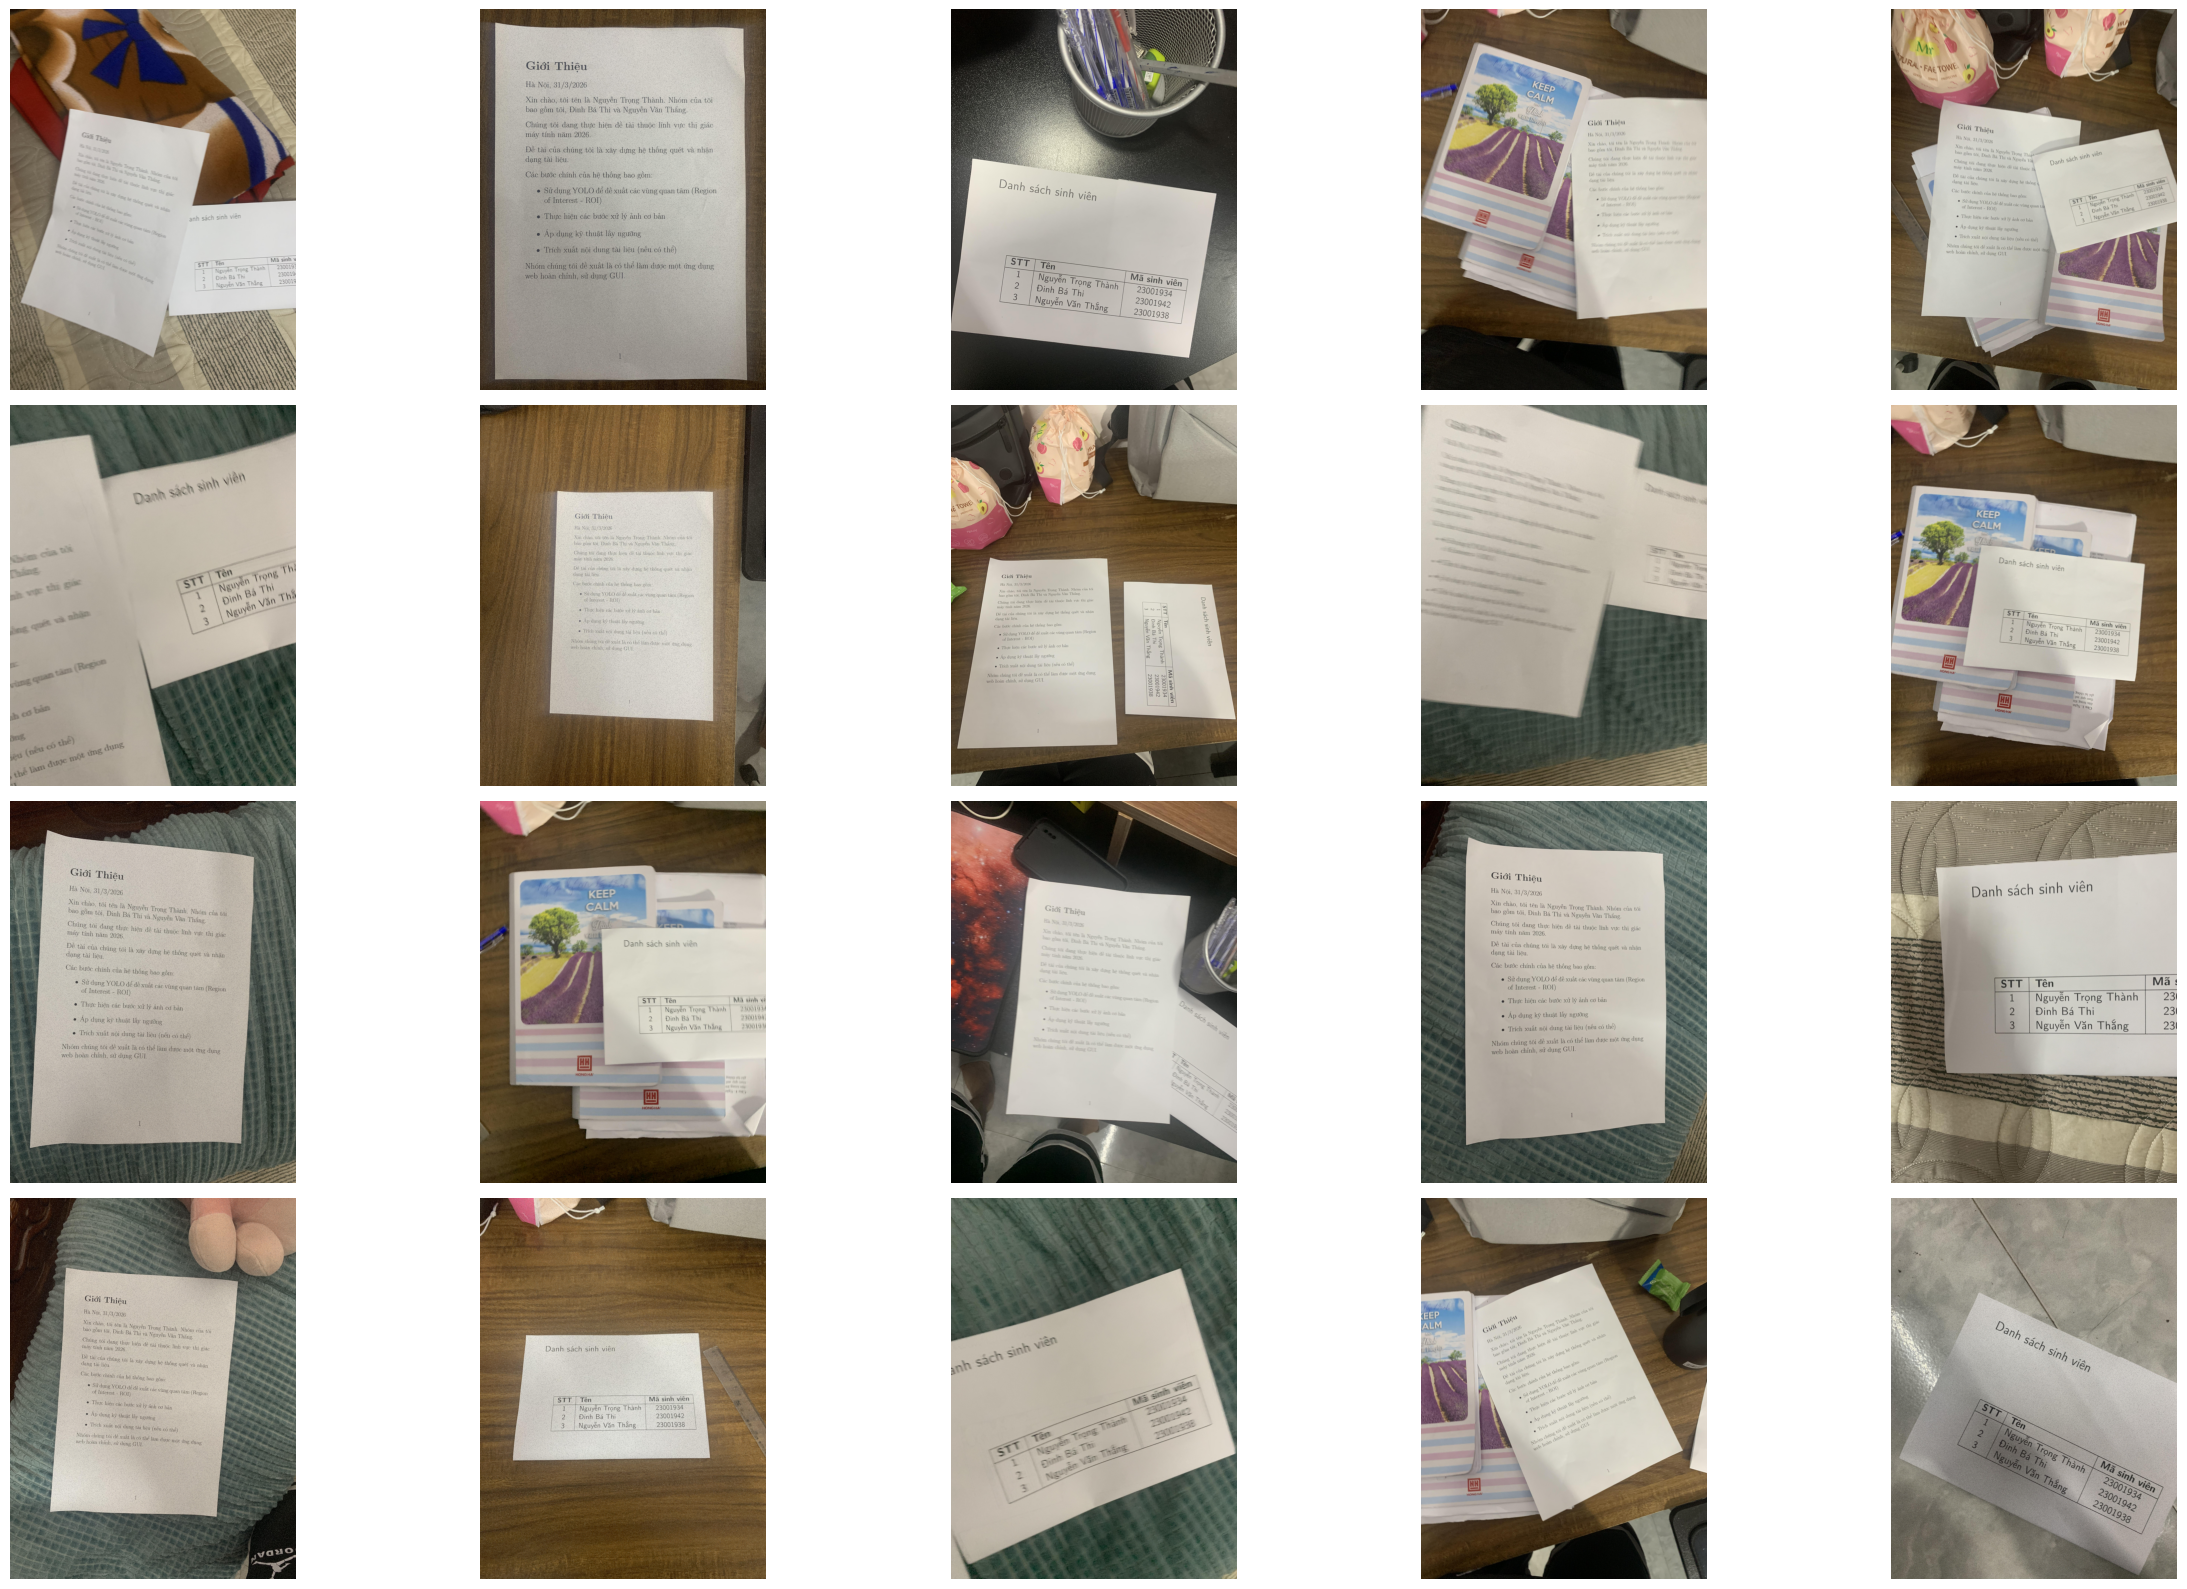

In [7]:
import random

random_paths = random.sample(image_paths, 20)
images = [
    read_rgb(str(i)) for i in random_paths
]

show(images, cols = 5)

## Lưu ý

Việc sử dụng toàn bộ hơn 370 ảnh có thể khiến thời gian chạy, dung lượng và tài nguyên chạy tăng lên rất nhiều, nên nhóm chúng tôi chỉ sử dụng một phần ảnh trong số hơn 370 ảnh trên để làm thực nghiệm. Ảnh được thực nghiệm vẫn sẽ có đủ đặc tính cần thiết, đảm bảo yêu cầu đề ra của giảng viên.